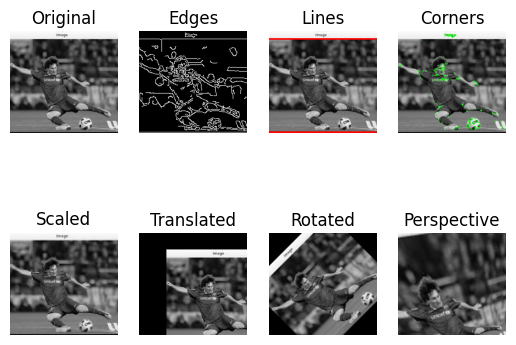

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("messi5.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --------------------
# 1. Edge Detection
# --------------------
edges = cv2.Canny(gray, 100, 200)

# --------------------
# 2. Line Detection
# --------------------
lines = cv2.HoughLines(edges, 1, np.pi/180, 150)
img_lines = img.copy()

if lines is not None:
    for rho, theta in lines[:,0]:
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a*rho, b*rho
        x1 = int(x0 + 1000*(-b))
        y1 = int(y0 + 1000*(a))
        x2 = int(x0 - 1000*(-b))
        y2 = int(y0 - 1000*(a))
        cv2.line(img_lines, (x1,y1), (x2,y2), (0,0,255), 2)

# --------------------
# 3. Corner Detection
# --------------------
corners = cv2.cornerHarris(gray, 2, 3, 0.04)
img_corners = img.copy()
img_corners[corners > 0.01 * corners.max()] = [0,255,0]

# --------------------
# 4. Scaling
# --------------------
scaled = cv2.resize(img, None, fx=0.5, fy=0.5)

# --------------------
# 5. Translation
# --------------------
rows, cols = gray.shape
M = np.float32([[1,0,50],[0,1,30]])
translated = cv2.warpAffine(img, M, (cols, rows))

# --------------------
# 6. Rotation
# --------------------
M_rot = cv2.getRotationMatrix2D((cols/2, rows/2), 45, 1)
rotated = cv2.warpAffine(img, M_rot, (cols, rows))

# --------------------
# 7. Perspective Transform
# --------------------
pts1 = np.float32([[50,50],[200,50],[50,200],[200,200]])
pts2 = np.float32([[10,100],[200,50],[100,250],[200,200]])

M_p = cv2.getPerspectiveTransform(pts1, pts2)
perspective = cv2.warpPerspective(img, M_p, (cols, rows))

# --------------------
# Display
# --------------------
titles = ["Original","Edges","Lines","Corners","Scaled","Translated","Rotated","Perspective"]
images = [img, edges, img_lines, img_corners, scaled, translated, rotated, perspective]

for i in range(8):
    plt.subplot(2,4,i+1)
    if i == 1:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis("off")

plt.show()